# Neural Network Analysis — Event Classification and Ep Spectrum Preservation

**Workflow:**
1. Data loading and preprocessing (StandardScaler)
2. Hyper-parameter optimization (Optuna) with combined objective: AUC + Ep spectrum preservation
3. Manual cross-validation with best params → loss/accuracy curves per fold, optimal epoch estimate
4. Final training on full X_train with fixed epochs (no early stopping)
5. Evaluation on X_test with full visualization suite
6. Background subtraction via temporal shifting (model-independent)


## 1 — Imports and configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, classification_report

# Custom modules
from create_datasets import dataset_creator
from nn_model import build_and_train_nn
from nn_optimization import optimize_nn_with_spectra, summarize_study
from nn_visualization import (
    plot_nn_training_curves,
    plot_nn_cv_curves,
    plot_score_distribution,
    plot_roc_curve,
    plot_pr_curve,
    plot_threshold_scan,
    plot_confusion_matrix,
    plot_energy_spectra,
    plot_efficiency,
    plot_score_vs_variable,
)
from build_pairs import generate_background_pairs, estimate_background_spectrum

warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline


# -- Device selection ------------------------------------------------
import torch
# from nn_model import get_device
# device = get_device()
device = torch.device("cpu")
print(f"Using device: {device}")


Using device: cpu


## 2 — Data paths and feature configuration

In [2]:
# =====================================================================
# ▶ INSERT THE CORRECT PATHS TO YOUR PARQUET FILES HERE
# =====================================================================
PATH_EVENTS     = "/Users/francesco/anaconda_projects/LCP-neutrino/events_tr.parquet"
PATH_BACKGROUND = "/Users/francesco/anaconda_projects/LCP-neutrino/background_tr.parquet"

# Target column
TARGET     = "is_event"

# Energy column to preserve (dropped from training features, kept for analysis)
ENERGY_COL = "Ep"

# Columns to drop from training features
DROP_COLS  = [TARGET, ENERGY_COL, 'E_sum', 'E_diff', 'theta_p', 'theta_d',
              'p_time', 'd_time', 'rp', 'rd', 'E_div', 'E_asym']


## 3 — Data loading

`dataset_creator` balances events and background, splits into train/test (80/20),
and returns the `Ep` column separately for spectral analysis.

In [3]:
X_train_full, X_test, y_train_full, y_test, Ep_train_full, Ep_test = dataset_creator(
    PATH_EVENTS,
    PATH_BACKGROUND,
    target=TARGET,
    drop=DROP_COLS,
    analysis_cols=[ENERGY_COL],
)

Ep_train_full = Ep_train_full[ENERGY_COL].values
Ep_test       = Ep_test[ENERGY_COL].values

print(f"Training set : {X_train_full.shape[0]:>8,} events — {X_train_full.shape[1]} features")
print(f"Test set     : {X_test.shape[0]:>8,} events")
print(f"Signal fraction (train): {y_train_full.mean():.3f}")
print(f"Signal fraction (test) : {y_test.mean():.3f}")
print(f"\nFeatures: {list(X_train_full.columns)}")


Training set :  159,912 events — 17 features
Test set     :   39,978 events
Signal fraction (train): 0.500
Signal fraction (test) : 0.500

Features: ['Ed', 'delta_x', 'delta_y', 'delta_z', 'zp', 'zd', 'edist', 'dist_wall_p', 'dist_wall_d', 'dist_wall_h_p', 'dist_wall_h_d', 'edist_over_r', 'delta_r', 'delta_theta', 'delta_t', 'diffusion', 'ds2']


## 4 — Internal train/val split and StandardScaler

This internal split is used **only** for the Optuna optimization.
The final training will use the full `X_train_full`.

In [4]:
X_train_opt, X_val_opt, y_train_opt, y_val_opt, Ep_train_opt, Ep_val_opt = train_test_split(
    X_train_full, y_train_full, Ep_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full,
)

# StandardScaler — fitted on the full training set
scaler = StandardScaler()
scaler.fit(X_train_full)
joblib.dump(scaler, "scaler.pkl") # Save scaler

X_train_full_sc = pd.DataFrame(scaler.transform(X_train_full), columns=X_train_full.columns)
X_train_opt_sc  = pd.DataFrame(scaler.transform(X_train_opt),  columns=X_train_opt.columns)
X_val_opt_sc    = pd.DataFrame(scaler.transform(X_val_opt),    columns=X_val_opt.columns)
X_test_sc       = pd.DataFrame(scaler.transform(X_test),       columns=X_test.columns)

print(f"Train (optimization)  : {X_train_opt_sc.shape[0]:>7,}")
print(f"Val   (optimization)  : {X_val_opt_sc.shape[0]:>7,}")
print(f"Train full (CV + final): {X_train_full_sc.shape[0]:>7,}")
print(f"Test                   : {X_test_sc.shape[0]:>7,}")


Train (optimization)  : 127,929
Val   (optimization)  :  31,983
Train full (CV + final): 159,912
Test                   :  39,978


## 5 — Hyper-parameter optimization (Optuna)

Combined objective: AUC − Wasserstein − χ² on the Ep spectrum.

In [5]:
best_params, study = optimize_nn_with_spectra(
    X_train=X_train_opt_sc.values,
    y_train=y_train_opt.values,
    X_val=X_val_opt_sc.values,
    y_val=y_val_opt.values,
    E_val=Ep_val_opt,
    E_truth_val=Ep_val_opt[y_val_opt.values == 1],
    selection_threshold=0.5,
    lambda_auc=1.0,
    lambda_wass=1.0,
    lambda_chi2=0.5,
    n_trials=80,
    device=device,
    sampler_seed=42,
    verbose=True,
)



 Trial │  Objective │      AUC │  Wasserstein │   χ² low-E │   N sel │ Status
───────────────────────────────────────────────────────────────────────────
     0 │  -0.500000 │ 0.995385 │       0.0544 │     0.0064 │   16130 │ ★ BEST
     1 │  -0.599173 │ 0.994501 │       0.0560 │     0.0073 │   16099 │ 
     2 │  -0.871169 │ 0.993771 │       0.0619 │     0.0093 │   16119 │ 
     3 │  -1.176643 │ 0.992835 │       0.0677 │     0.0119 │   16141 │ 
     4 │  -0.681417 │ 0.994796 │       0.0561 │     0.0083 │   16115 │ 
     5 │  -1.323337 │ 0.991037 │       0.0760 │     0.0118 │   16171 │ 
     6 │  -1.329875 │ 0.991696 │       0.0727 │     0.0126 │   16161 │ 
     7 │  -0.806023 │ 0.993879 │       0.0600 │     0.0089 │   16106 │ 
     8 │  -0.452161 │ 0.995270 │       0.0511 │     0.0065 │   16041 │ ★ BEST
     9 │  -1.031326 │ 0.993539 │       0.0663 │     0.0103 │   16216 │ 
    10 │  -0.324260 │ 0.995655 │       0.0518 │     0.0047 │   16100 │ ★ BEST
    11 │  -0.275359 │ 0.995782 │   

In [6]:
summarize_study(study, top_n=10)



  STUDY: 80 completed trials
 Rank │  Trial │  Objective │      AUC │  Wasserstein │   χ² low-E │   N sel
────────────────────────────────────────────────────────────────────────────────
    1 │     64 │  -0.234350 │ 0.995637 │       0.0455 │     0.0051 │   15991
    2 │     42 │  -0.243861 │ 0.995703 │       0.0472 │     0.0048 │   16023
    3 │     54 │  -0.266328 │ 0.995787 │       0.0480 │     0.0049 │   16013
    4 │     53 │  -0.268238 │ 0.995739 │       0.0473 │     0.0051 │   15973
    5 │     11 │  -0.275359 │ 0.995782 │       0.0486 │     0.0049 │   16045
    6 │     23 │  -0.286206 │ 0.995483 │       0.0461 │     0.0056 │   15936
    7 │     62 │  -0.290690 │ 0.995766 │       0.0476 │     0.0053 │   16033
    8 │     51 │  -0.291877 │ 0.995771 │       0.0494 │     0.0049 │   16067
    9 │     45 │  -0.293788 │ 0.995643 │       0.0492 │     0.0050 │   16023
   10 │     10 │  -0.324260 │ 0.995655 │       0.0518 │     0.0047 │   16100

  Best hyper-parameters (trial #64)
─────

## 6 — Cross-Validation with best parameters

5-fold stratified CV on `X_train_full` to:
- Check for overfitting (loss curves per fold)
- Determine the **optimal number of epochs** (mean of best epochs across folds)

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Extract architecture params from the optimization results
hidden_dims  = best_params["hidden_dims"]
dropout      = best_params["dropout"]
lr           = best_params["lr"]
weight_decay = best_params["weight_decay"]
batch_size   = best_params["batch_size"]

fold_aucs = []
fold_best_epochs = []
fold_histories = []

for i, (train_idx, val_idx) in enumerate(cv.split(X_train_full_sc, y_train_full)):
    X_tr = X_train_full_sc.iloc[train_idx].values
    X_vl = X_train_full_sc.iloc[val_idx].values
    y_tr = y_train_full.iloc[train_idx].values
    y_vl = y_train_full.iloc[val_idx].values

    model_cv, hist_cv = build_and_train_nn(
        X_train=X_tr,
        y_train=y_tr,
        X_val=X_vl,
        y_val=y_vl,
        hidden_dims=hidden_dims,
        dropout=dropout,
        lr=lr,
        weight_decay=weight_decay,
        batch_size=batch_size,
        epochs=60,
        patience=10,
        device=device,
        random_state=42,
        verbose=0,
    )

    best_ep = int(np.argmin(hist_cv["val_loss"])) + 1
    fold_best_epochs.append(best_ep)
    fold_histories.append(hist_cv)

    scores_vl = model_cv.predict_proba(X_vl)
    auc_vl = roc_auc_score(y_vl, scores_vl)
    fold_aucs.append(auc_vl)

    print(f"  Fold {i+1}: AUC = {auc_vl:.4f}  |  best epoch = {best_ep}")

n_epochs_optimal = int(np.mean(fold_best_epochs))

print(f"\nBest epochs per fold  : {fold_best_epochs}")
print(f"Optimal epochs (mean) : {n_epochs_optimal}")
print(f"AUC mean              : {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")


  Fold 1: AUC = 0.9955  |  best epoch = 16
  Fold 2: AUC = 0.9957  |  best epoch = 17
  Fold 3: AUC = 0.9956  |  best epoch = 19
  Fold 4: AUC = 0.9956  |  best epoch = 27
  Fold 5: AUC = 0.9953  |  best epoch = 28

Best epochs per fold  : [16, 17, 19, 27, 28]
Optimal epochs (mean) : 21
AUC mean              : 0.9956 ± 0.0001


### Loss curves per fold

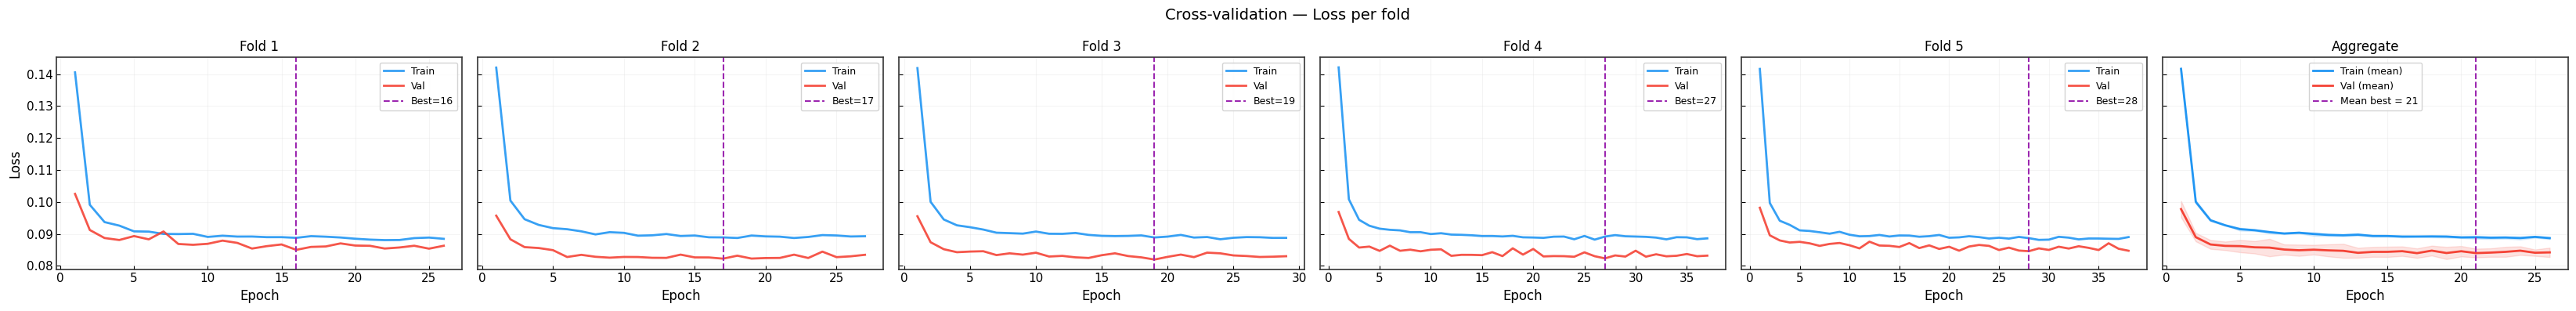

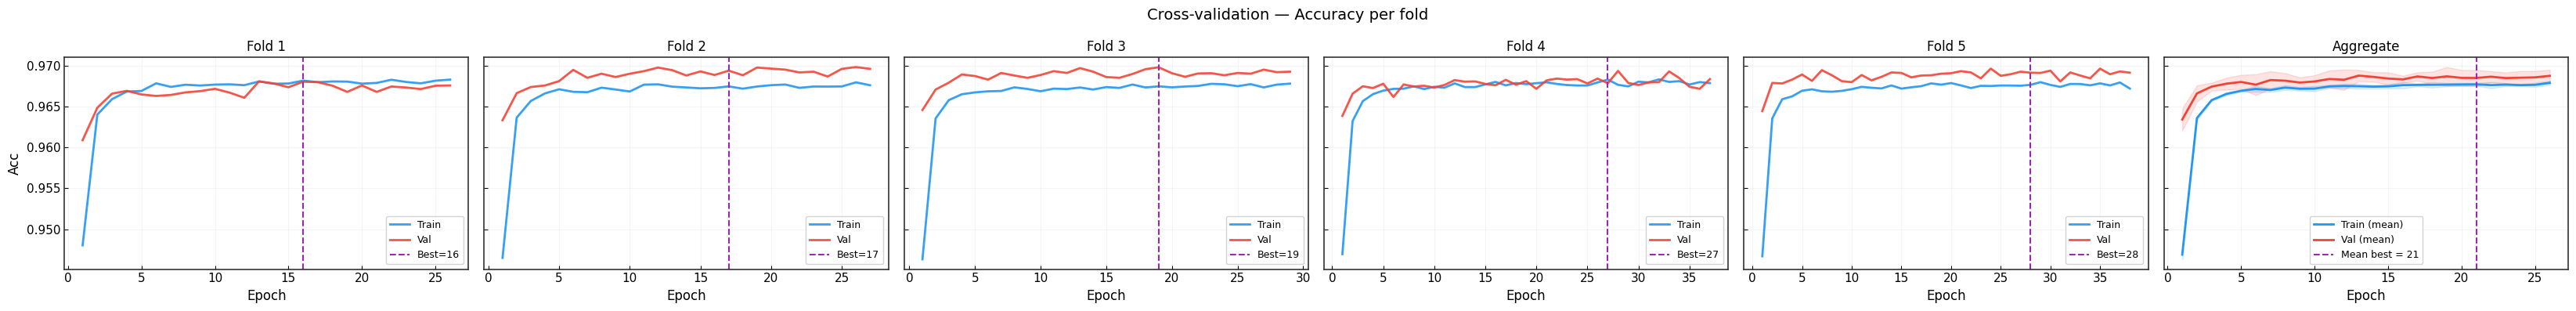

In [8]:
plot_nn_cv_curves(
    fold_histories,
    best_epochs=fold_best_epochs,
    metric="loss",
    title="Cross-validation — Loss per fold",
)
plt.show()

plot_nn_cv_curves(
    fold_histories,
    best_epochs=fold_best_epochs,
    metric="acc",
    title="Cross-validation — Accuracy per fold",
)
plt.show()


## 7 — Final training on full X_train

The model is trained on the **entire** `X_train_full` with the number of
epochs determined by cross-validation. No early stopping — `X_test` is
passed only as an eval set for monitoring.

In [9]:
model, history = build_and_train_nn(
    X_train=X_train_full_sc.values,
    y_train=y_train_full.values,
    X_val=X_test_sc.values,
    y_val=y_test.values,
    hidden_dims=hidden_dims,
    dropout=dropout,
    lr=lr,
    weight_decay=weight_decay,
    batch_size=batch_size,
    epochs=n_epochs_optimal,
    patience=0,            # disabled — train for exactly n_epochs_optimal
    device=device,
    random_state=42,
    verbose=1,
)

print(f"\nTraining complete: {n_epochs_optimal} epochs")


  Training on device: cpu
  Epoch   1/21  loss=0.1337  acc=0.9508  val_loss=0.0978  val_acc=0.9642
  Epoch   2/21  loss=0.0979  acc=0.9647  val_loss=0.0927  val_acc=0.9661
  Epoch   3/21  loss=0.0931  acc=0.9662  val_loss=0.0901  val_acc=0.9664
  Epoch   4/21  loss=0.0921  acc=0.9667  val_loss=0.0907  val_acc=0.9665
  Epoch   5/21  loss=0.0916  acc=0.9667  val_loss=0.0905  val_acc=0.9669
  Epoch   6/21  loss=0.0910  acc=0.9672  val_loss=0.0895  val_acc=0.9670
  Epoch   7/21  loss=0.0898  acc=0.9674  val_loss=0.0885  val_acc=0.9675
  Epoch   8/21  loss=0.0902  acc=0.9672  val_loss=0.0893  val_acc=0.9669
  Epoch   9/21  loss=0.0902  acc=0.9670  val_loss=0.0882  val_acc=0.9675
  Epoch  10/21  loss=0.0895  acc=0.9674  val_loss=0.0893  val_acc=0.9663
  Epoch  11/21  loss=0.0897  acc=0.9671  val_loss=0.0890  val_acc=0.9673
  Epoch  12/21  loss=0.0897  acc=0.9674  val_loss=0.0883  val_acc=0.9672
  Epoch  13/21  loss=0.0893  acc=0.9677  val_loss=0.0880  val_acc=0.9673
  Epoch  14/21  loss=0.08

In [10]:
torch.save({
    "state_dict": model.state_dict(),
    "hidden_dims": hidden_dims,
    "dropout": dropout,
    "n_features": X_train_full_sc.shape[1],
    "feature_cols": list(X_train_full.columns),
}, "nn_ibd_model.pt")

## 8 — Evaluation on the test set

In [11]:
scores_test = model.predict_proba(X_test_sc.values)
auc_test = roc_auc_score(y_test, scores_test)
print(f"AUC on test set: {auc_test:.4f}")


AUC on test set: 0.9949


## 9 — Visualizations

### 9.1 — Training curves (final model)

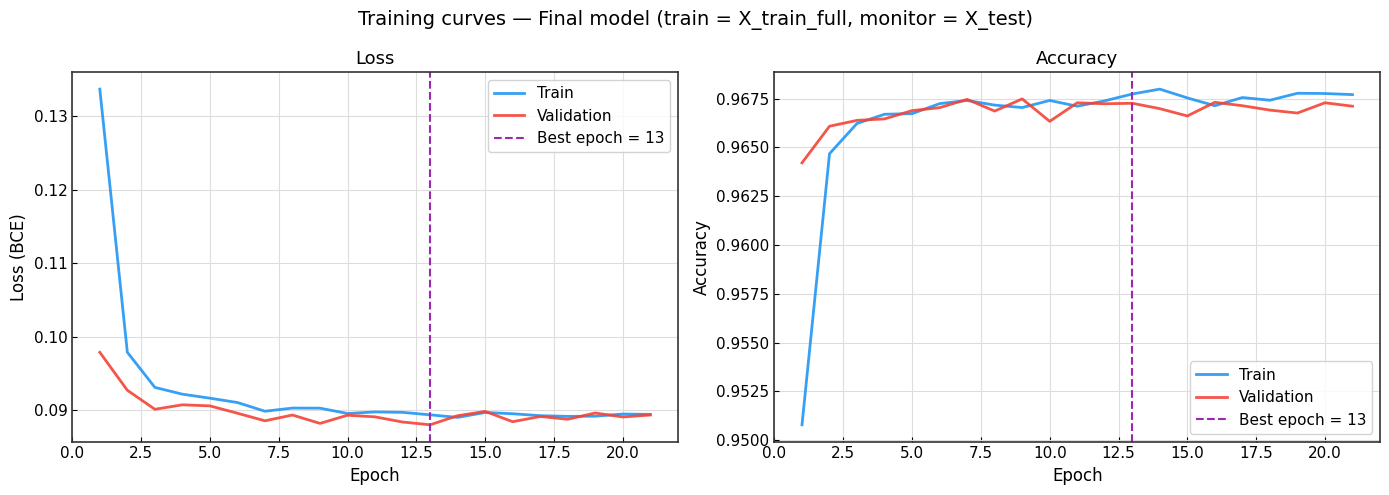

In [12]:
plot_nn_training_curves(
    history,
    title="Training curves — Final model (train = X_train_full, monitor = X_test)",
)
plt.show()


### 9.2 — Score distribution

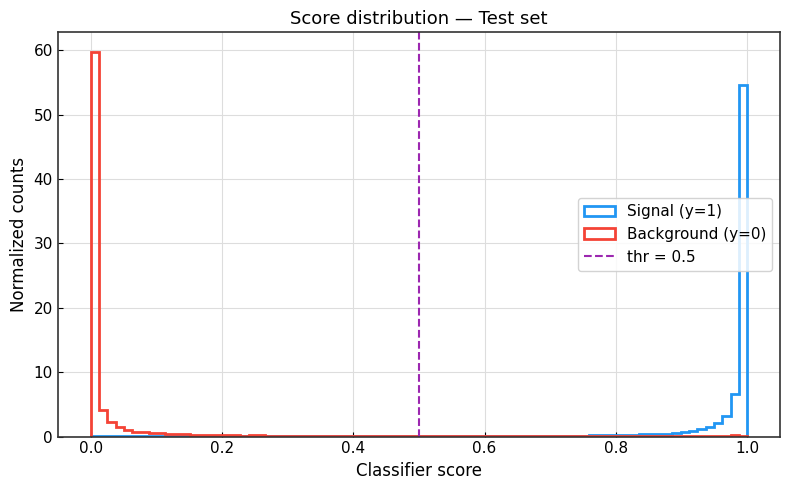

In [13]:
plot_score_distribution(
    scores_test,
    y_test.values,
    thresholds=[0.5],
    threshold_labels=["thr = 0.5"],
    title="Score distribution — Test set",
)
plt.show()


### 9.3 — ROC curve

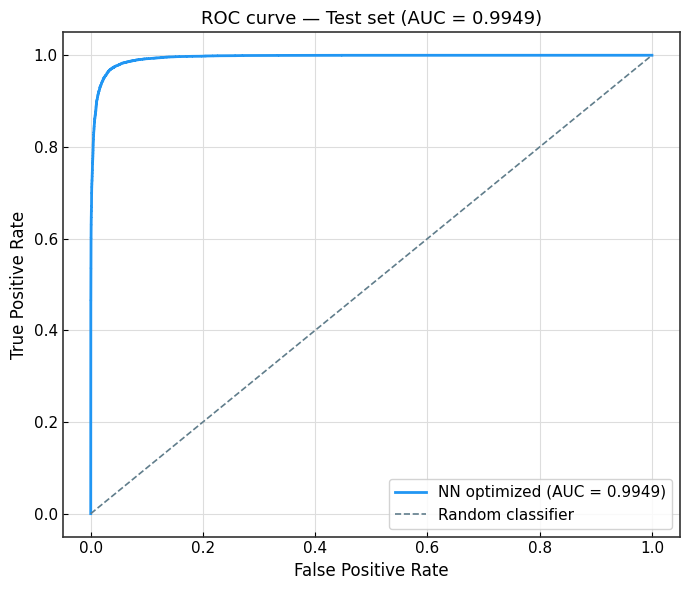

In [14]:
plot_roc_curve(
    y_test.values,
    scores_test,
    label="NN optimized",
    title=f"ROC curve — Test set (AUC = {auc_test:.4f})",
)
plt.show()


### 9.4 — Precision-Recall curve

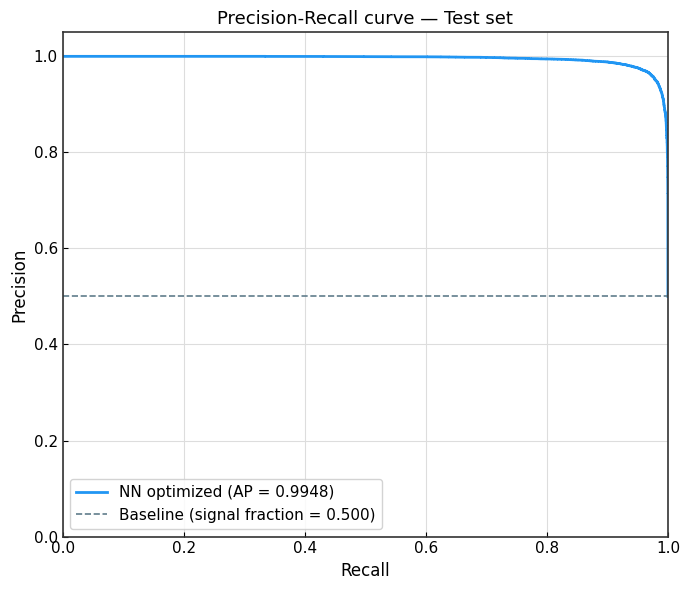

In [15]:
plot_pr_curve(
    y_test.values,
    scores_test,
    label="NN optimized",
    title="Precision-Recall curve — Test set",
)
plt.show()


### 9.5 — Threshold scan


Optimal threshold (max F1): 0.5276


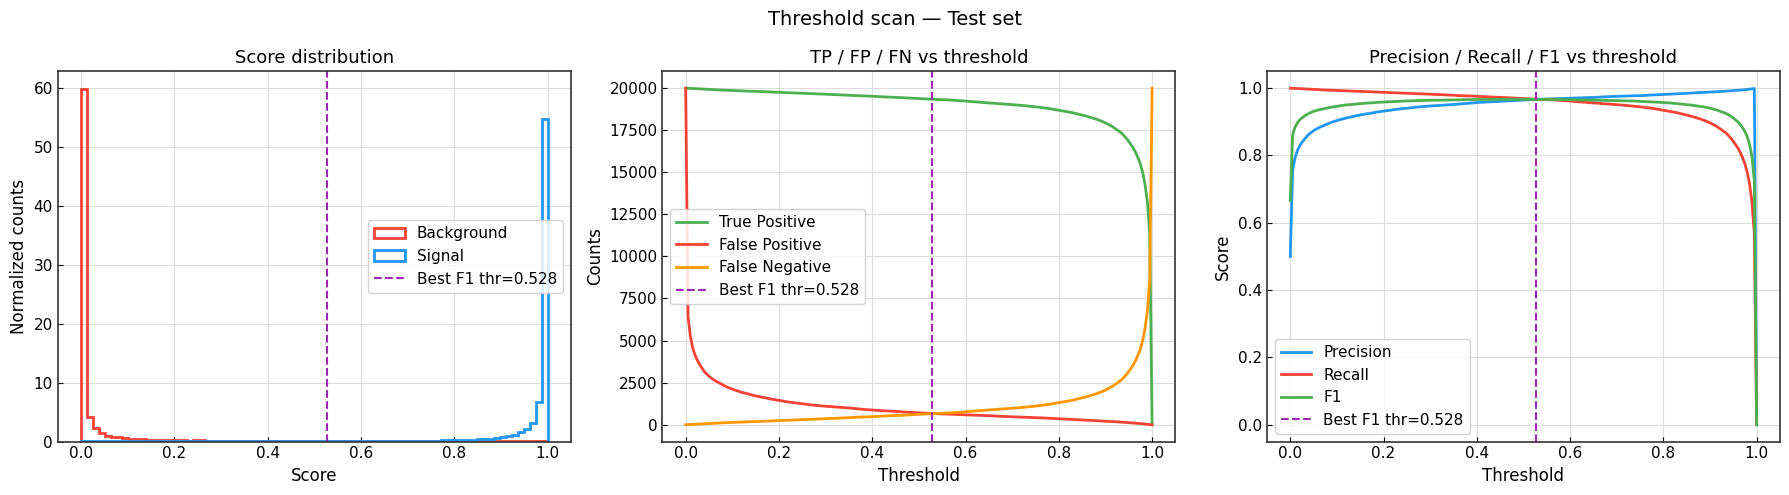

In [16]:
_, best_thr = plot_threshold_scan(
    y_test.values,
    scores_test,
    title="Threshold scan — Test set",
)
print(f"\nOptimal threshold (max F1): {best_thr:.4f}")
plt.show()


### 9.6 — Confusion matrix

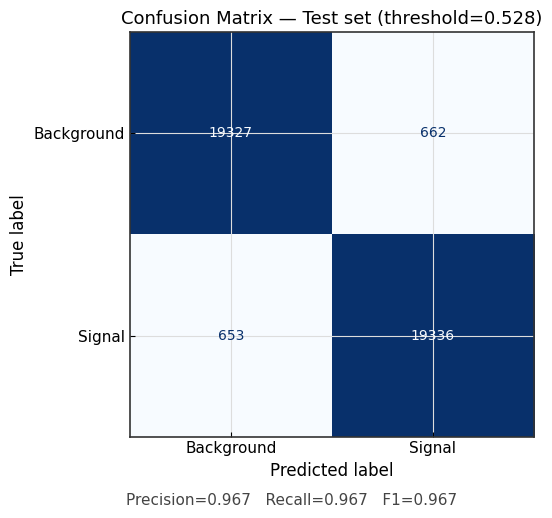


              precision    recall  f1-score   support

  Background       0.97      0.97      0.97     19989
      Signal       0.97      0.97      0.97     19989

    accuracy                           0.97     39978
   macro avg       0.97      0.97      0.97     39978
weighted avg       0.97      0.97      0.97     39978



In [17]:
y_pred_test = (scores_test > best_thr).astype(int)

plot_confusion_matrix(
    y_test.values,
    y_pred_test,
    threshold=best_thr,
    title="Confusion Matrix — Test set",
)
plt.show()

print("\n" + classification_report(
    y_test, y_pred_test,
    target_names=["Background", "Signal"],
))


### 9.7 — Ep spectrum comparison (ground truth vs selected)

Key plot: the spectrum of model-selected events should overlap the true
signal spectrum without distortion.

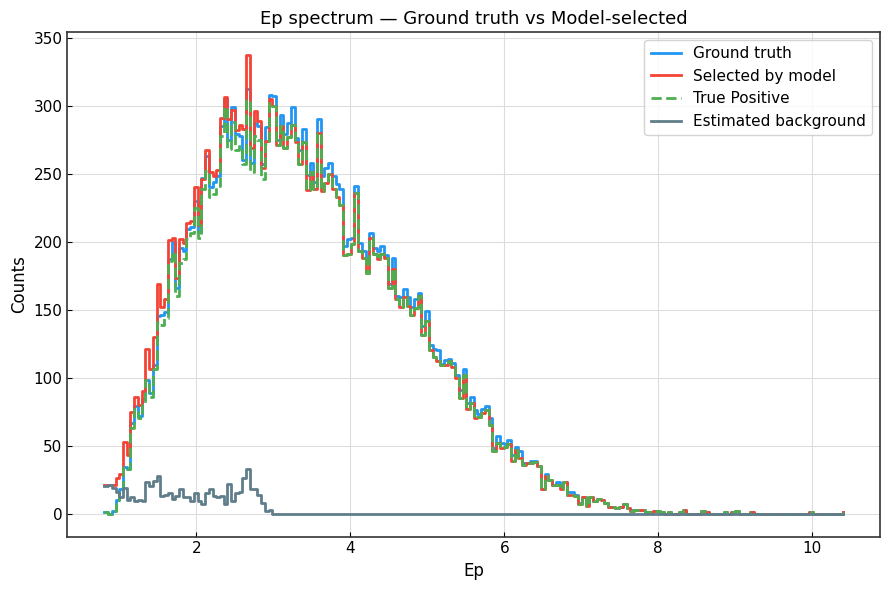

In [18]:
Ep_true_signal = Ep_test[y_test.values == 1]

selected_mask = scores_test > best_thr
Ep_selected   = Ep_test[selected_mask]

tp_mask = selected_mask & (y_test.values == 1)
Ep_tp   = Ep_test[tp_mask]

fp_mask = selected_mask & (y_test.values == 0)
Ep_fp   = Ep_test[fp_mask]

plot_energy_spectra(
    E_true=Ep_true_signal,
    E_selected=Ep_selected,
    E_tp=Ep_tp,
    E_background=Ep_fp,
    bins=200,
    log_y=False,
    x_label="Ep",
    title="Ep spectrum — Ground truth vs Model-selected",
)
plt.show()


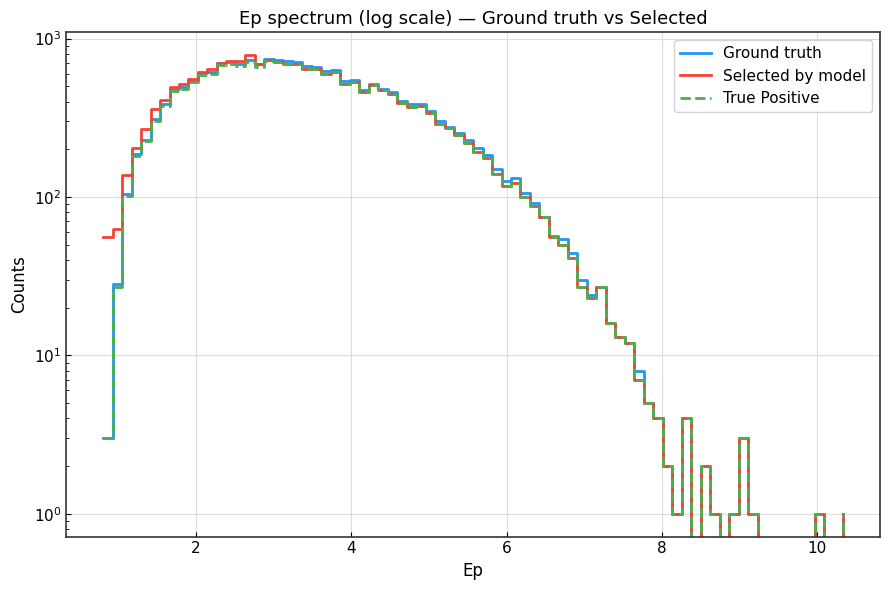

In [19]:
plot_energy_spectra(
    E_true=Ep_true_signal,
    E_selected=Ep_selected,
    E_tp=Ep_tp,
    bins=80,
    log_y=True,
    x_label="Ep",
    title="Ep spectrum (log scale) — Ground truth vs Selected",
)
plt.show()


### 9.8 — Normalized Ep spectrum overlay

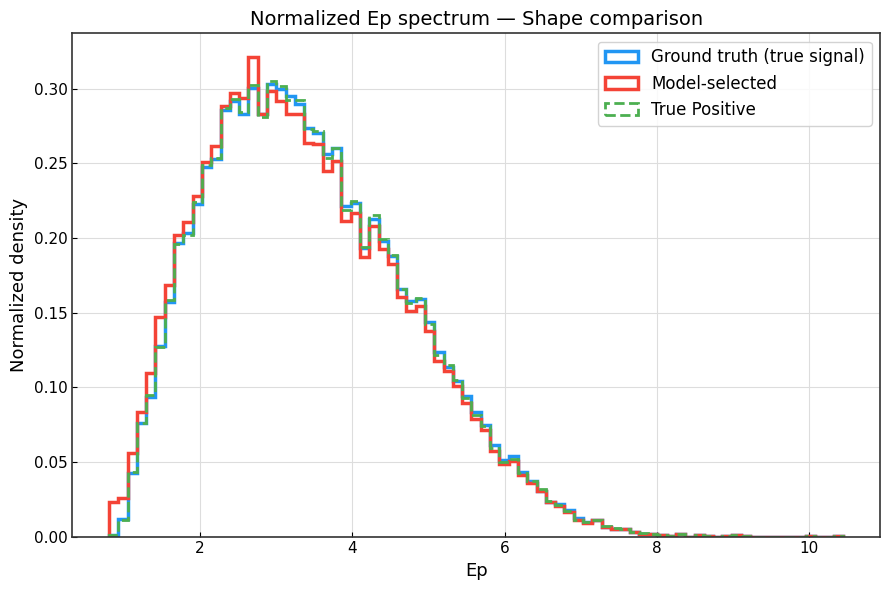

Wasserstein distance (truth vs selected): 0.057575
Wasserstein distance (truth vs TP)      : 0.004995


In [20]:
from scipy.stats import wasserstein_distance

fig, ax = plt.subplots(figsize=(9, 6))

bins_ep = np.linspace(
    min(Ep_true_signal.min(), Ep_selected.min()),
    max(Ep_true_signal.max(), Ep_selected.max()),
    80,
)

ax.hist(Ep_true_signal, bins=bins_ep, histtype="step", linewidth=2.5,
        density=True, color="#2196F3", label="Ground truth (true signal)")
ax.hist(Ep_selected, bins=bins_ep, histtype="step", linewidth=2.5,
        density=True, color="#F44336", label="Model-selected")
ax.hist(Ep_tp, bins=bins_ep, histtype="step", linewidth=2, linestyle="--",
        density=True, color="#4CAF50", label="True Positive")

ax.set_xlabel("Ep", fontsize=13)
ax.set_ylabel("Normalized density", fontsize=13)
ax.set_title("Normalized Ep spectrum — Shape comparison", fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

wd = wasserstein_distance(Ep_true_signal, Ep_selected)
print(f"Wasserstein distance (truth vs selected): {wd:.6f}")
wd_tp = wasserstein_distance(Ep_true_signal, Ep_tp)
print(f"Wasserstein distance (truth vs TP)      : {wd_tp:.6f}")


### 9.9 — Spectrum ratio (selected / truth)

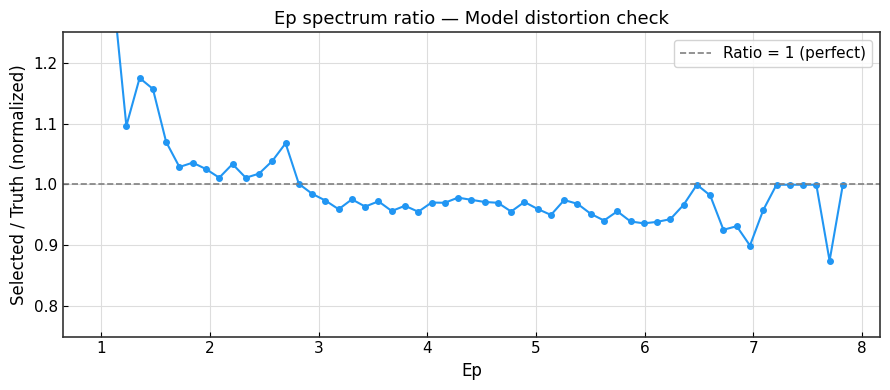

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))

h_truth, bin_edges = np.histogram(Ep_true_signal, bins=bins_ep)
h_sel, _           = np.histogram(Ep_selected,    bins=bins_ep)

h_truth_norm = h_truth / (h_truth.sum() + 1e-12)
h_sel_norm   = h_sel   / (h_sel.sum()   + 1e-12)

ratio = h_sel_norm / (h_truth_norm + 1e-12)
ratio[h_truth < 5] = np.nan

centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

ax.plot(centers, ratio, marker="o", markersize=4, color="#2196F3", linewidth=1.5)
ax.axhline(1.0, linestyle="--", color="grey", linewidth=1.2, label="Ratio = 1 (perfect)")
ax.set_xlabel("Ep", fontsize=12)
ax.set_ylabel("Selected / Truth (normalized)", fontsize=12)
ax.set_title("Ep spectrum ratio — Model distortion check", fontsize=13)
ax.set_ylim([0.75, 1.25])
ax.legend()
plt.tight_layout()
plt.show()


### 9.10 — Selection efficiency vs Ep

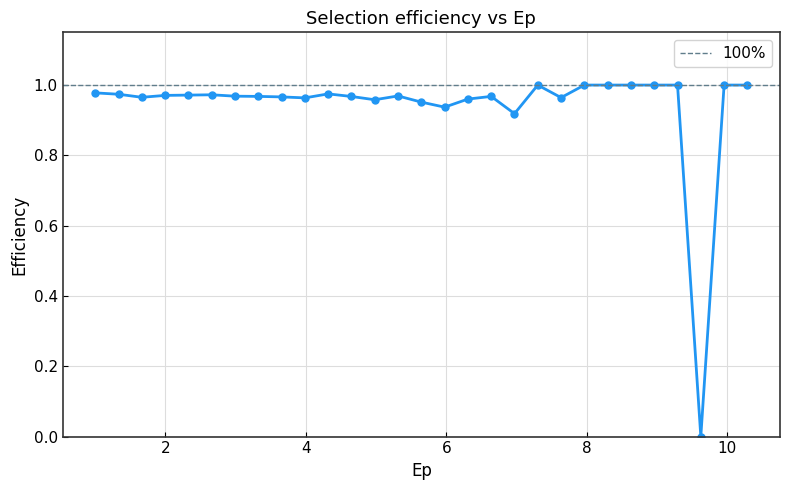

In [22]:
plot_efficiency(
    E_before=Ep_true_signal,
    E_after=Ep_tp,
    bins=30,
    log_x=False,
    x_label="Ep",
    title="Selection efficiency vs Ep",
)
plt.show()


### 9.11 — Residual correlation: Score vs Ep

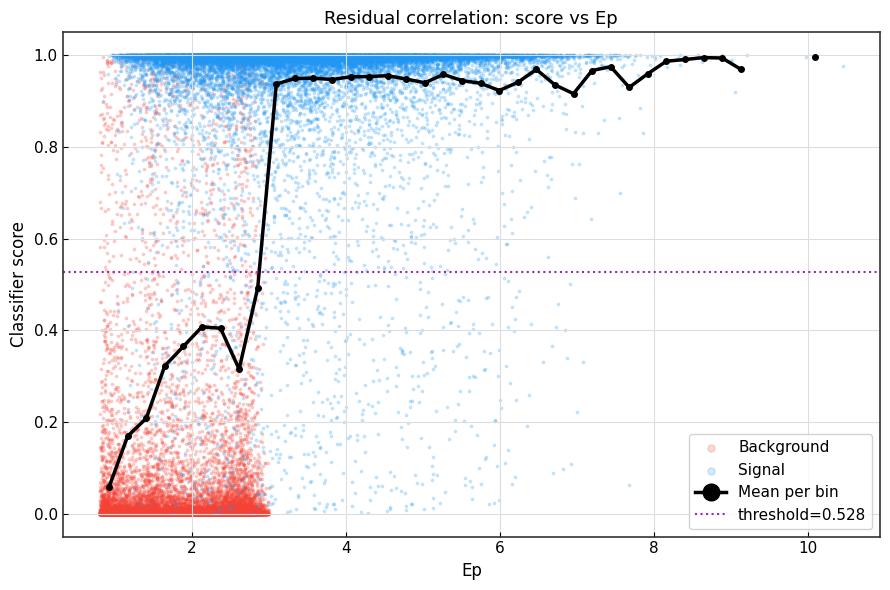

In [23]:
plot_score_vs_variable(
    variable=Ep_test,
    scores=scores_test,
    y_true=y_test.values,
    threshold=best_thr,
    var_label="Ep",
    title="Residual correlation: score vs Ep",
)
plt.show()


## 10 — Background subtraction via temporal shifting

Following the approach of `workflow_ordinato.ipynb`, the accidental
background contamination of the selected sample is estimated data-drivenly:
events that are far apart in real time are paired together (so any genuine
time correlation is destroyed) and their time separation is relabelled to
fall inside the physical coincidence window through a large negative
**temporal shift**.

The key point for this analysis: the shifted pairs are built with the
**exact same feature set and transformations** used for training (those
created in `dataset_setup.ipynb`), then the unused columns (`DROP_COLS`)
are removed, so the trained network can be applied directly.

This is handled by `background_pairs.py`, which is model-independent.

**Required input:** the raw single-event tables `events.parquet` and
`truth.parquet` (event-level, *before* pair construction).

### 10.1 — Load raw single-event data and detector geometry

In [ ]:
from build_pairs import (
    generate_background_pairs,
    estimate_background_spectrum,
    compute_detector_geometry,
)

# =====================================================================
# Raw single-event tables (event-level, before pair construction).
# These are the same files used as input by dataset_setup.ipynb.
# =====================================================================
PATH_RAW_EVENTS = "/Users/francesco/anaconda_projects/LCP-neutrino/data/training/events.parquet"

raw_events = pd.read_parquet(PATH_RAW_EVENTS)

# Ensure the columns are in the expected order [time, energy, x, y, z]
# and the stream is sorted by time (required by the pairing kernel).
raw_events = raw_events[["time", "energy", "x", "y", "z"]].sort_values("time").reset_index(drop=True)

# Detector geometry (R_DET, Z_MAX) — computed exactly as in dataset_setup
R_DET, Z_MAX = compute_detector_geometry(raw_events)

print(f"Raw events: {len(raw_events):,}")
print(f"R_DET = {R_DET:.4f}   Z_MAX = {Z_MAX:.4f}")

ModuleNotFoundError: No module named 'background_pairs'

### 10.2 — Generate shifted background pairs and apply the NN

`generate_background_pairs` reconstructs every feature of
`dataset_setup.ipynb` for each shift and applies the same transformations.
We then drop `DROP_COLS`, reorder the columns to match the training
features, scale with the **same** fitted `scaler`, and select events with
the model.

In [ ]:
# Temporal shifts (same as workflow_ordinato: 10 large negative offsets)
shifts = 1e6 * np.arange(-20, -10, 1)

# Build the transformed background DataFrames (one per shift)
bg_dfs, shifts_used = generate_background_pairs(
    raw_events,
    shifts=shifts,
    R_DET=R_DET,
    Z_MAX=Z_MAX,
    max_dt=2e6,
    apply_transforms=True,   # apply the dataset_setup sqrt/log10/log transforms
)

print(f"Generated {len(bg_dfs)} background datasets")
print(f"Pairs per shift: {[len(df) for df in bg_dfs]}")

# Training feature order (must match what the scaler/model expect)
feature_cols = list(X_train_full.columns)

bg_selected_masks = []
for df in bg_dfs:
    # Drop unused columns, keep only the training features in the right order
    X_bg = df.drop(columns=DROP_COLS)[feature_cols]
    X_bg_sc = scaler.transform(X_bg)
    bg_scores = model.predict_proba(X_bg_sc)
    bg_selected_masks.append(bg_scores > best_thr)

print(f"Mean selected fraction per shift: "
      f"{np.mean([m.mean() for m in bg_selected_masks]):.4f}")

### 10.3 — Estimate the background Ep spectrum

The selected-background Ep histograms are averaged over the shifts and
scaled by a normalization factor (`norm_factor`), reproducing
`workflow_ordinato.ipynb`'s estimate
`(1/n_shifts) * 0.28 * sum(histograms)`.

> **Note:** `norm_factor` (0.28 in the original workflow) is the ratio of
> the physical coincidence window to the total shifted window and should
> be adjusted to your dataset.

In [ ]:
# Shared binning with the signal spectra
bins_ep = np.linspace(
    float(min(Ep_true_signal.min(), Ep_selected.min())),
    float(max(Ep_true_signal.max(), Ep_selected.max())),
    200,
)

norm_factor = 0.2 # test dataset fraction

histo_background = estimate_background_spectrum(
    bg_dfs,
    bg_selected_masks,
    bins=bins_ep,
    energy_col="Ep",
    norm_factor=norm_factor,
)

print(f"Background estimated from {len(shifts_used)} shifts")
print(f"Total estimated background counts: {histo_background.sum():.1f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.stairs(histo_background, bins_ep, color="#607D8B", linewidth=2,
          label="Estimated accidental background")
ax.set_xlabel("Ep")
ax.set_ylabel("Counts")
ax.set_title("Estimated background Ep spectrum (averaged over shifts)")
ax.legend()
plt.tight_layout()
plt.show()

### 10.4 — Background-subtracted Ep spectrum

In [ ]:
# Signal-region histograms on the SAME binning
histo_truth,    _ = np.histogram(Ep_true_signal, bins=bins_ep)  # true IBD
histo_selected, _ = np.histogram(Ep_selected,    bins=bins_ep)  # all NN-selected
histo_tp,       _ = np.histogram(Ep_tp,          bins=bins_ep)  # true positives
histo_fp,       _ = np.histogram(Ep_fp,          bins=bins_ep)  # false positives

histo_subtracted = histo_selected - histo_background

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1 — all spectra overlaid
ax = axes[0]
ax.stairs(histo_truth,      bins_ep, label="True IBD",             color="#2196F3", linewidth=2)
ax.stairs(histo_selected,   bins_ep, label="NN selected",          color="#F44336", linewidth=2)
ax.stairs(histo_fp,         bins_ep, label="False positives",      color="#FF9800", linewidth=1.5)
ax.stairs(histo_background, bins_ep, label="Estimated background", color="#607D8B", linewidth=2)
ax.set_xlabel("Ep")
ax.set_ylabel("Counts")
ax.set_title("Ep spectra — Test set")
ax.legend()

# Panel 2 — truth vs background-subtracted
ax = axes[1]
ax.stairs(histo_truth,      bins_ep, label="True IBD",                color="#2196F3", linewidth=2)
ax.stairs(histo_subtracted, bins_ep, label="NN selected - background", color="#4CAF50", linewidth=2)
ax.set_xlabel("Ep")
ax.set_ylabel("Counts")
ax.set_title("Ep spectrum - Background subtracted")
ax.legend()

plt.tight_layout()
plt.show()

### 10.5 — Closure check

How well the background-subtracted spectrum recovers the true IBD spectrum
(ideally the ratio is close to 1 across the energy range).

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

centers = 0.5 * (bins_ep[:-1] + bins_ep[1:])
ratio = histo_subtracted / (histo_truth + 1e-9)
ratio[histo_truth < 5] = np.nan   # ignore low-statistics bins

ax.plot(centers, ratio, marker="o", markersize=3, color="#4CAF50", linewidth=1.2)
ax.axhline(1.0, linestyle="--", color="grey", linewidth=1.2, label="Perfect recovery")
ax.set_xlabel("Ep")
ax.set_ylabel("(Selected - Bkg) / Truth")
ax.set_title("Background-subtraction closure")
ax.set_ylim([0.5, 1.5])
ax.legend()
plt.tight_layout()
plt.show()

# Integral comparison
print(f"True IBD integral          : {histo_truth.sum():.0f}")
print(f"Subtracted integral        : {histo_subtracted.sum():.0f}")
print(f"Relative difference        : "
      f"{100*(histo_subtracted.sum() - histo_truth.sum())/histo_truth.sum():+.2f}%")

## 11 — Final summary

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

prec = precision_score(y_test, y_pred_test)
rec  = recall_score(y_test, y_pred_test)
f1   = f1_score(y_test, y_pred_test)

print("=" * 70)
print("  RESULTS SUMMARY")
print("=" * 70)
print(f"  AUC (test)             : {auc_test:.4f}")
print(f"  AUC (CV mean ± std)    : {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"  Optimal threshold (F1) : {best_thr:.4f}")
print(f"  Precision              : {prec:.4f}")
print(f"  Recall                 : {rec:.4f}")
print(f"  F1-score               : {f1:.4f}")
print(f"  Wasserstein (spectrum) : {wd:.6f}")
print(f"  Optimal epochs (from CV): {n_epochs_optimal}")
print(f"  Events selected        : {selected_mask.sum()} / {len(y_test)}")
print("=" * 70)
print("\n  Optimal hyper-parameters:")
print("-" * 40)
print(f"    {'hidden_dims':22s}: {hidden_dims}")
print(f"    {'dropout':22s}: {dropout}")
print(f"    {'lr':22s}: {lr}")
print(f"    {'weight_decay':22s}: {weight_decay}")
print(f"    {'batch_size':22s}: {batch_size}")
print("=" * 70)
